In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("C:/Users/Prathmesh Ingole/Downloads/lemma_industry_grade_doooh_dataset.csv")
df

,CampaignID,Client,Industry,City,ScreenType,AdType,Impressions,Clicks,CTR,Spend_INR,...,weather_condition,time_slot,adjusted_impressions,cpm,revenue,ad_spend,roi_percent,click_through_rate,estimated_clicks,campaign_performance
0,C0001,Pepsi,Retail,Hyderabad,Metro Screen,Programmatic,438323,20025,4.57,404785,...,Sunny,Morning,22718,102.10,2319.51,1552.91,49.37,4.53,1029,High Performing
1,C0002,OnePlus,Entertainment,Pune,Outdoor Billboard,Video,365631,4044,1.11,314951,...,Sunny,Evening,8423,328.51,2767.04,1956.50,41.43,5.32,448,Moderate
2,C0003,Boat,Entertainment,Bangalore,Shopping Mall Screen,Image,472481,7742,1.64,447833,...,Rainy,Evening,44236,295.42,13068.20,11364.52,14.99,4.48,1981,Low Performing
3,C0004,Netflix,Technology,Delhi,Metro Screen,Programmatic,100707,2453,2.44,249191,...,Foggy,Evening,46623,446.38,20811.57,12825.91,62.26,1.78,829,High Performing
4,C0005,Paytm,Technology,Pune,Shopping Mall Screen,HTML,339428,7374,2.17,91313,...,Sunny,Evening,23408,168.49,3944.01,2176.14,81.24,4.38,1025,High Performing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C0996,Apple,Fintech,Mumbai,Airport Screen,HTML,161707,1631,1.01,188805,...,Rainy,Night,7466,153.44,1145.58,852.13,34.44,4.54,338,Moderate
996,C0997,OnePlus,Entertainment,Bangalore,Airport Screen,Programmatic,494780,14611,2.95,373878,...,Rainy,Evening,48002,141.01,6768.76,4938.10,37.07,5.12,2457,Moderate
997,C0998,Nike,Audio Tech,Ahmedabad,Airport Screen,HTML,233354,10642,4.56,52702,...,Sunny,Night,28596,168.80,4827.00,3130.25,54.20,3.50,1000,High Performing
998,C0999,Adidas,Food,Pune,Outdoor Billboard,HTML,327398,10009,3.06,94430,...,Sunny,Evening,40717,342.75,13955.75,11691.85,19.36,0.98,399,Low Performing


1.REVENUE ANALYSIS

In [3]:
revenue_by_time = df.groupby('time_slot')['revenue'].sum()

print(revenue_by_time)

time_slot
Afternoon    2207923.83
Evening      2678172.88
Morning      1835674.63
Night         696851.97
Name: revenue, dtype: float64


Here we can clearly see the maximun revenue are come from evening slot

In [4]:
revenue_by_weather = df.groupby('weather_condition')['revenue'].sum()

print(revenue_by_weather)

weather_condition
Cloudy    1651729.77
Foggy      473388.26
Rainy     1749189.69
Sunny     3544315.59
Name: revenue, dtype: float64


Here we can clearly see the maximun revenue are come in Sunny weather

In [5]:
top_screen = df.groupby('CampaignID')['revenue'].sum().sort_values(ascending=False).head(10)

print(top_screen)

CampaignID
C0018    28152.70
C0767    27153.92
C0219    25896.74
C0993    25002.71
C0185    24915.17
C0830    24845.09
C0146    24832.30
C0488    24770.58
C0815    23667.66
C0671    23380.70
Name: revenue, dtype: float64


REVENUE CAMPARISON CHART

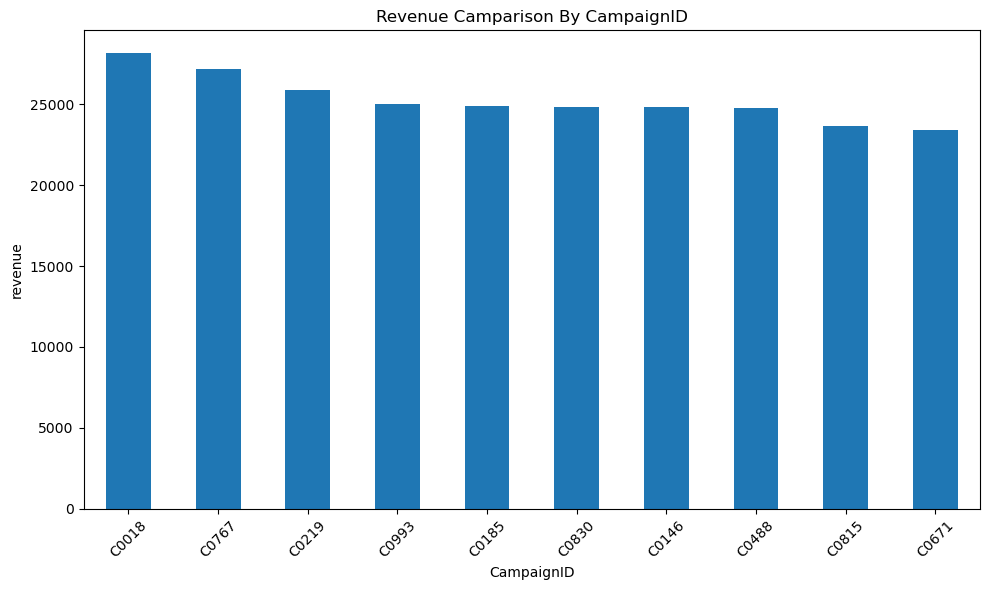

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top_screen.plot(kind='bar')


plt.xlabel("CampaignID")
plt.ylabel("revenue")
plt.title("Revenue Camparison By CampaignID")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

2. Return of Investment Analysis

In [7]:
roi_time= df.groupby('time_slot')['roi_percent'].mean()

print(roi_time)

time_slot
Afternoon    41.869443
Evening      40.476000
Morning      45.158880
Night        41.558681
Name: roi_percent, dtype: float64


Morning session are more Return of investment

In [8]:
roi_weather= df.groupby('weather_condition')['roi_percent'].mean()

print(roi_weather)

weather_condition
Cloudy    41.278543
Foggy     44.338804
Rainy     42.595432
Sunny     42.017541
Name: roi_percent, dtype: float64


Foggy Weather got more Return of Investment

Cloudy weather make less return of investment

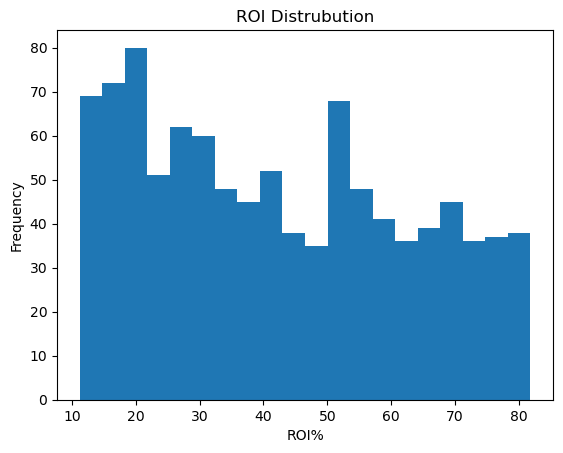

In [9]:
import matplotlib.pyplot as plt
plt.hist(df['roi_percent'],bins=20)
plt.xlabel("ROI%")
plt.ylabel("Frequency")
plt.title("ROI Distrubution")
plt.show()

3.Audience Engagement Analtysis

In [10]:
ctr_analysis = df.groupby('time_slot')['click_through_rate'].mean()

print(ctr_analysis)

time_slot
Afternoon    3.190627
Evening      3.289903
Morning      3.266795
Night        3.188264
Name: click_through_rate, dtype: float64


Correlation Between Impressions and Revenue

In [11]:
correlation=df[['adjusted_impressions','revenue']].corr()
print(correlation)

                      adjusted_impressions   revenue
adjusted_impressions              1.000000  0.781595
revenue                           0.781595  1.000000


Correlation Heatmap 


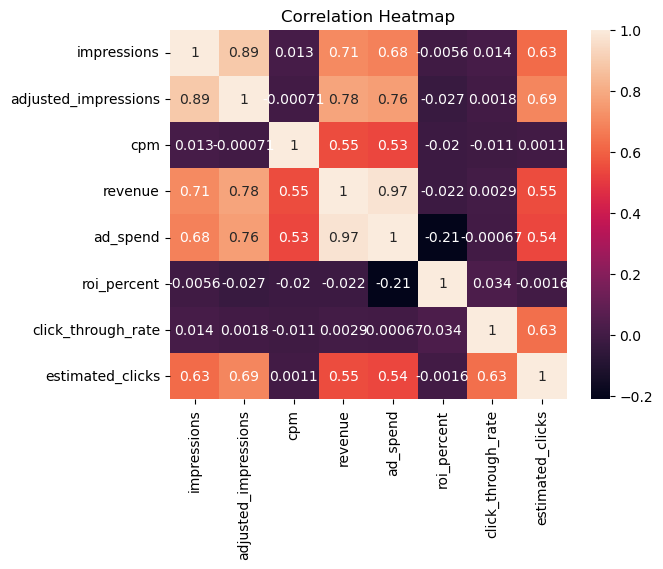

In [13]:
import seaborn as sns

numeric_col=['impressions',
            'adjusted_impressions',
            'cpm',
            'revenue',
            'ad_spend',
            'roi_percent',
            'click_through_rate',
            'estimated_clicks'
            ]
corr=df[numeric_col].corr()

sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

Campaign Performance Analysis

Performance Distribution

In [15]:
performance_count=df['campaign_performance'].value_counts()
print(performance_count)

campaign_performance
High Performing    438
Moderate           386
Low Performing     176
Name: count, dtype: int64


Revenue by Campaign performance

In [16]:
perf_revenue=df.groupby('campaign_performance')['revenue'].mean()
print(perf_revenue)

campaign_performance
High Performing    7325.071096
Low Performing     7692.396534
Moderate           7399.949171
Name: revenue, dtype: float64


ADVANCED INSIGHTS

Best combination

In [24]:
best_combo=df.groupby(['weather_condition','time_slot'])['revenue'].mean()

best_combo = best_combo.sort_values(ascending=False)
print(best_combo)
print(best_combo.idxmax())
print(best_combo.max())

weather_condition  time_slot
Cloudy             Evening      9625.405000
Sunny              Evening      9037.421628
                   Afternoon    8777.012049
Cloudy             Afternoon    8722.319298
Sunny              Morning      8168.261429
Rainy              Evening      8061.853372
Cloudy             Morning      7549.486098
Rainy              Afternoon    6103.043636
                   Morning      5909.100000
Foggy              Evening      5809.910000
Cloudy             Night        5524.202903
Sunny              Night        5502.780656
Foggy              Afternoon    5484.574194
                   Morning      4844.330690
Rainy              Night        3828.865333
Foggy              Night        2519.017143
Name: revenue, dtype: float64
('Cloudy', 'Evening')
9625.404999999999


HIGH ROI SCREENS

In [25]:
best_roi_screens=df.groupby('screen_id')['roi_percent'].mean().sort_values(ascending=False).head(10)
print(best_roi_screens)

screen_id
DEL-SCR-1532    81.80
DEL-SCR-1836    81.71
PUN-SCR-1345    81.66
MUM-SCR-1989    81.63
MUM-SCR-1004    81.24
MUM-SCR-1903    81.23
BLR-SCR-1344    81.20
HYD-SCR-1240    81.10
DEL-SCR-1868    81.03
PUN-SCR-1649    80.97
Name: roi_percent, dtype: float64


CPM Efficiency

In [26]:
cpm_efficiency=df.groupby('time_slot')['cpm'].mean()
print(cpm_efficiency)

time_slot
Afternoon    276.317979
Evening      261.858323
Morning      277.496757
Night        277.468264
Name: cpm, dtype: float64
